📊 MARKETING CAMPAIGN ANALYSIS (Pandas + Visualization Notes)


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
os.getcwd()

'/Users/ruturajmokashi/Python Course/chap_16'

In [9]:
os.listdir()

['marketing_campaign.ipynb', 'pandas_concept.md']

In [10]:
dataset_path = "/Users/ruturajmokashi/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8"

os.listdir(dataset_path)

['marketing_campaign.xlsx', 'marketing_campaign.csv']

In [13]:
# 📥 STEP 2 — Load dataset correctly

file_path = os.path.join(dataset_path, "marketing_campaign.csv")

df = pd.read_csv(file_path, sep=";") # ; removed the messy data, check the file what symbol is there

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [16]:
# df.shape
# df.info()

# df.shape
# df.info(}
🧠 What this tells us
number of customers (rows)
number of features (columns)
data types (important for analysis readiness)

In [19]:
# Basic Data Health Check

df.isnull().sum().sort_values(ascending=False)


Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Key finding:
Income missing = 24 values (~1%)

👉 Very small → safe to fix

❗ Data issues discovered
1. Extreme income
max = 666,666
normal ~ 50,000

👉 likely outlier or error

2. Unrealistic birth year
min = 1893

👉 invalid age (>130 years)

3. Constant columns
Z_CostContact
Z_Revenue

👉 useless for analysis

In [18]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000



df.isnull().sum().sort_values(ascending=False)
df.describe()

👉 This tells you:

broken columns
missing values
wrong data types

In [20]:
# 🧼 STEP 4 — DATA CLEANING + FEATURES
# 💰 Fix missing income

df["Income"] = df["Income"].fillna(df["Income"].median())

In [ ]:
# 🎂 Create Age
df["Age"] = 2026 - df["Year_Birth"]

In [21]:
# Create total spend

df["Total_Spend"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [22]:
# Remove useless columns

df = df.drop(columns=["Z_CostContact", "Z_Revenue"])

STEP 5 — EXPLORATORY ANALYSIS (BEHAVIOR)

💰 Income stats
avg ≈ 52K
median ≈ 51K

👉 stable middle-class customer base

👨‍👩‍👧 Family structure
kids avg: 0.44
teens avg: 0.50

👉 mostly small households

🛒 Spending pattern
Category	Insight
Wines	highest spending
Meat	second
Fruits	very low

👉 wine is core product

🛍️ Channel behavior
Store purchases > Web purchases
Web visits high

👉 customers research online, buy offline

In [23]:
#📉 Response rate
df["Response"].mean() # -14.9% Meaning Campaign is weak OR poorly targeted 85% ignore marketing

np.float64(0.14910714285714285)

## RFM Analysis

In [32]:
df["Recency_Score"] = pd.qcut(df["Recency"], 5, labels=[5,4,3,2,1]).astype(int)

df["Frequency_Score"] = pd.qcut(df["Frequency"], 5, labels=[1,2,3,4,5]).astype(int)

df["Monetary_Score"] = pd.qcut(df["Total_Spend"], 5, labels=[1,2,3,4,5]).astype(int)

In [33]:
df["RFM_Score"] = (
    df["Recency_Score"] +
    df["Frequency_Score"] +
    df["Monetary_Score"]
)

📊 STEP 5 — EXPLORATORY ANALYSIS (PROFESSIONAL PLOTS)

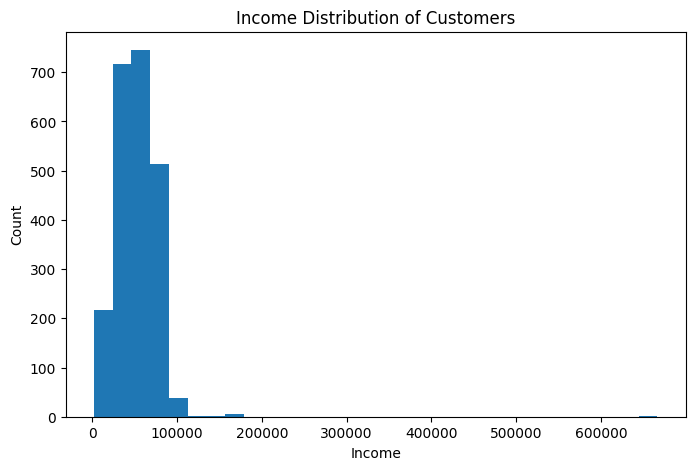

In [34]:
# Income Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Income"], bins=30)
plt.title("Income Distribution of Customers")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

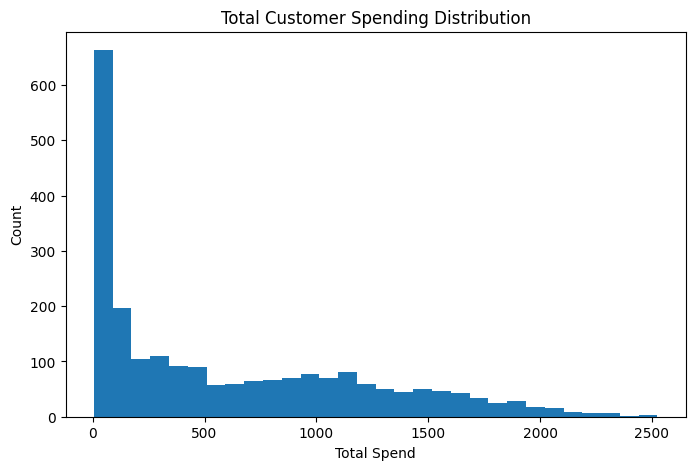

In [36]:
# 2. Total Spend Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Total_Spend"], bins=30)
plt.title("Total Customer Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Count")
plt.show()

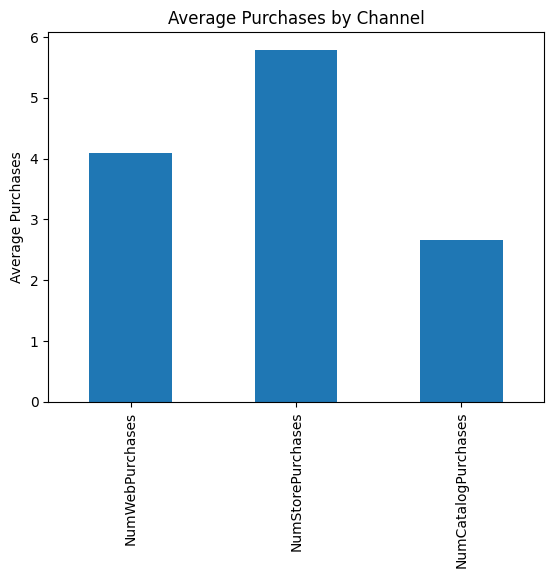

In [37]:
# 📦 3. Purchase Channel Comparison

channels = [
    "NumWebPurchases",
    "NumStorePurchases",
    "NumCatalogPurchases"
]

df[channels].mean().plot(kind="bar")
plt.title("Average Purchases by Channel")
plt.ylabel("Average Purchases")
plt.show()

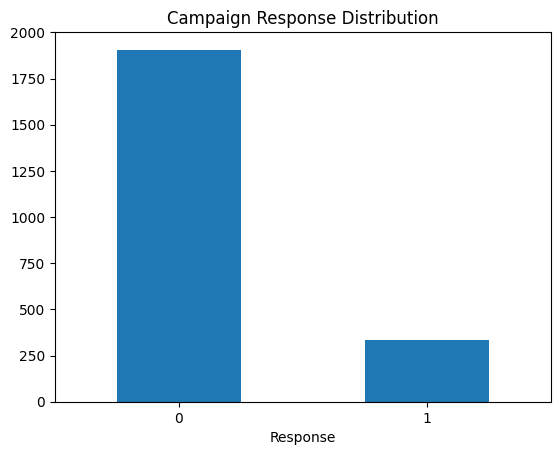

In [38]:
# 🎯 4. Campaign Response Rate

df["Response"].value_counts().plot(kind="bar")
plt.title("Campaign Response Distribution")
plt.xticks(rotation=0)
plt.show()

🧠 STEP 6 — BUSINESS INSIGHTS (FROM DATA)
📌 Key findings:
Income is moderately distributed (middle-class dominant)
Wine is the highest spending category
Store purchases dominate online channels
Campaign response rate is low (~15%)

👉 Conclusion:

Marketing is not optimized — segmentation is needed

🧩 STEP 8 — CUSTOMER SEGMENTS

In [39]:
def segment(row):
    if row["RFM_Score"] >= 13:
        return "Champions"
    elif row["RFM_Score"] >= 10:
        return "Loyal Customers"
    elif row["RFM_Score"] >= 7:
        return "Potential Customers"
    else:
        return "At Risk"

df["Segment"] = df.apply(segment, axis=1)

📊 STEP 9 — SEGMENT VISUALIZATION

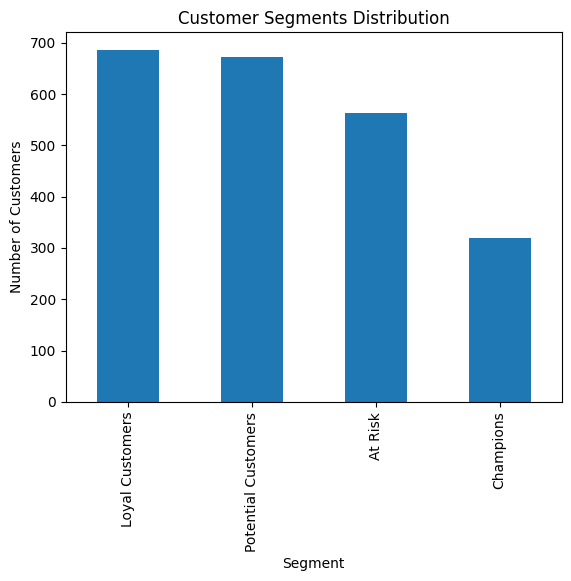

In [40]:
# 👥 Segment distribution

df["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments Distribution")
plt.ylabel("Number of Customers")
plt.show()

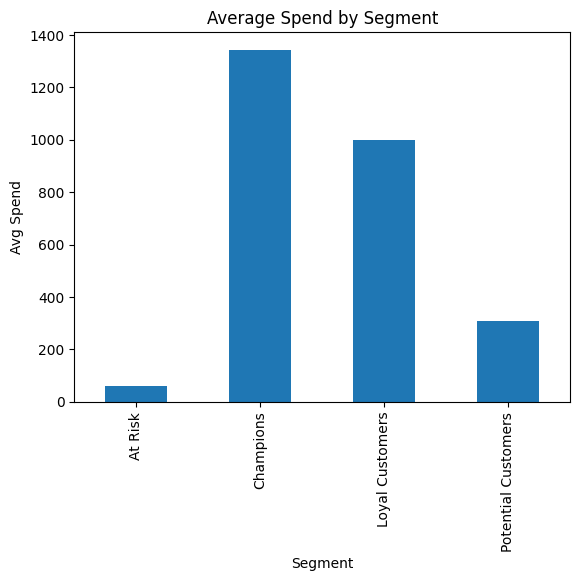

In [41]:
# 💰 Spend by segment

df.groupby("Segment")["Total_Spend"].mean().plot(kind="bar")
plt.title("Average Spend by Segment")
plt.ylabel("Avg Spend")
plt.show()

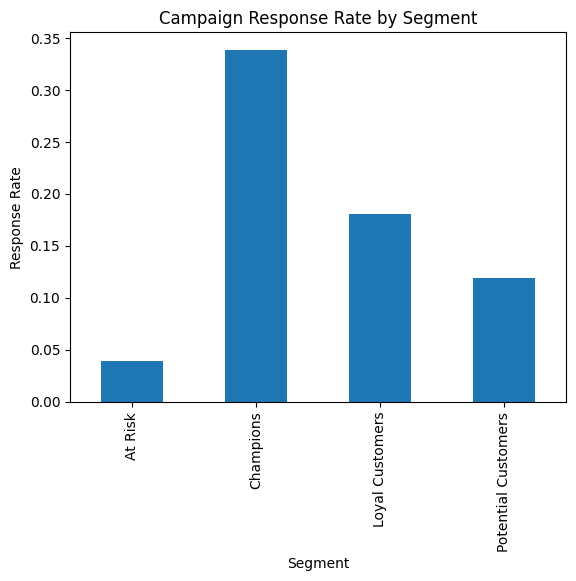

In [42]:
# 🎯 Response rate by segment

df.groupby("Segment")["Response"].mean().plot(kind="bar")
plt.title("Campaign Response Rate by Segment")
plt.ylabel("Response Rate")
plt.show()